In [1]:
%pip install pandas numpy requests matplotlib datetime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.3/209.3 kB 10.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


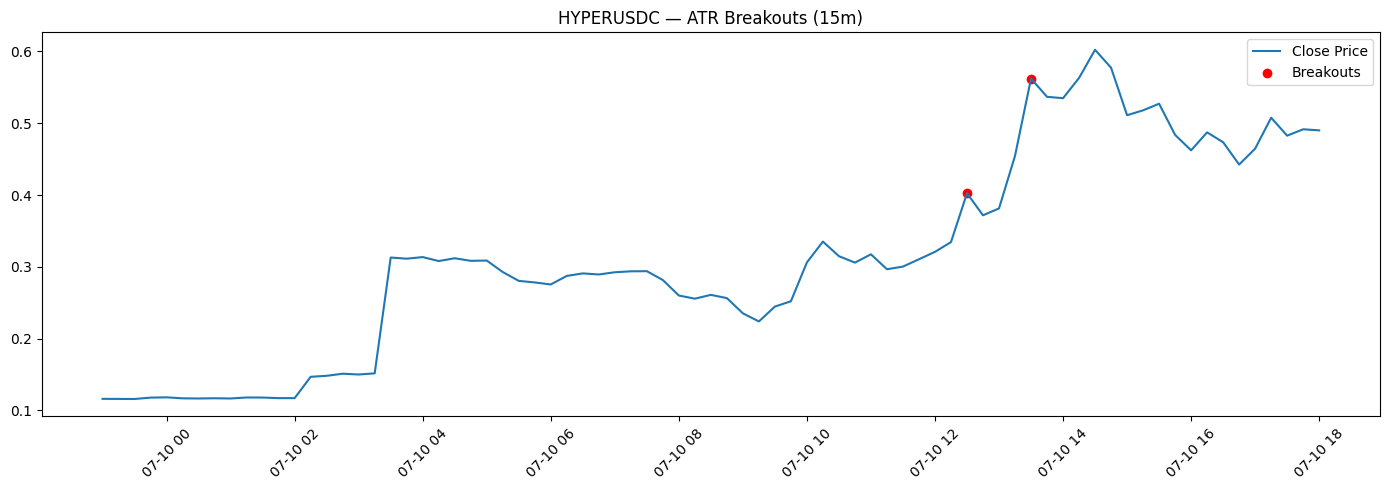

                      close      ATR  rolling_high  breakout_strength
open_time                                                            
2025-07-10 12:30:00  0.4025  0.03280        0.3419           1.847561
2025-07-10 13:30:00  0.5623  0.07628        0.4546           1.411904


In [2]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from datetime import datetime, timezone

# Convert datetime to milliseconds since epoch
def to_ms(dt_str):
    dt = datetime.strptime(dt_str, "%Y-%m-%d %H:%M").replace(tzinfo=timezone.utc)
    return int(dt.timestamp() * 1000)

# Parameters
symbol = "HYPERUSDC"
interval = "15m"
start_time = to_ms("2025-07-09 23:00")
end_time = int(datetime.now(tz=timezone.utc).timestamp() * 1000)

# Fetch data in chunks (max 1500 candles per request)
def fetch_binance_klines(symbol, interval, start_ms, end_ms):
    url = "https://api.binance.com/api/v3/uiKlines"
    all_data = []
    while start_ms < end_ms:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": start_ms,
            "endTime": end_ms,
            "limit": 1500
        }
        resp = requests.get(url, params=params)
        data = resp.json()
        if not data:
            break
        all_data.extend(data)
        last_close = data[-1][0]
        start_ms = last_close + 1  # Prevent duplication
    return all_data

# Fetch and format data
raw_data = fetch_binance_klines(symbol, interval, start_time, end_time)
df = pd.DataFrame(raw_data, columns=[
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "num_trades",
    "taker_buy_base_vol", "taker_buy_quote_vol", "ignore"
])
df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
df.set_index("open_time", inplace=True)
df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].astype(float)

# ATR breakout logic
tr = pd.concat([
    df["high"] - df["low"],
    (df["high"] - df["close"].shift()).abs(),
    (df["low"] - df["close"].shift()).abs()
], axis=1).max(axis=1)

df["ATR"] = tr.rolling(window=5, min_periods=5).mean()
df["rolling_high"] = df["high"].rolling(window=20).max().shift(1)
df["ATR_breakout"] = df["close"] > (df["rolling_high"] + 0.8 * df["ATR"])
df["breakout_strength"] = (df["close"] - df["rolling_high"]) / df["ATR"]

# Plot close and breakouts
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["close"], label="Close Price")
plt.scatter(df[df["ATR_breakout"]].index, df[df["ATR_breakout"]]["close"], color='red', label="Breakouts")
plt.title(f"{symbol} — ATR Breakouts (15m)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Show breakout rows
print(df[df["ATR_breakout"]][["close", "ATR", "rolling_high", "breakout_strength"]].tail(10))
